In [26]:
# Import Statements
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from sklearn.datasets import fetch_lfw_people
from torchvision import transforms

import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# loading data and splitting them in X and y(target)
data = fetch_lfw_people(color=True)
X = data.images
y = data.target
X.shape,y.shape

((13233, 62, 47, 3), (13233,))

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,shuffle =True)

In [29]:
#Converting to Images to Tensor
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_test  = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

In [30]:
# TensorDataset pairs input features (X) with their corresponding labels (y)
# Each item in the dataset is returned as (X[i], y[i])
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [31]:
# Access a single sample from the dataset
# This helps verify the shape of one data sample
first_sample, _ = train_dataset[0]
print(f"Shape of one sample: {first_sample.shape}")

Shape of one sample: torch.Size([3, 62, 47])


In [32]:
# DataLoader for training data
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)
# DataLoader for test/validation data
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)
# Get the first batch from the training DataLoader
X_batch, y_batch = next(iter(train_loader))
print(f"Training batch input shape: {X_batch.shape}")
print(f"Training batch labels shape: {y_batch.shape}")

Training batch input shape: torch.Size([32, 3, 62, 47])
Training batch labels shape: torch.Size([32])


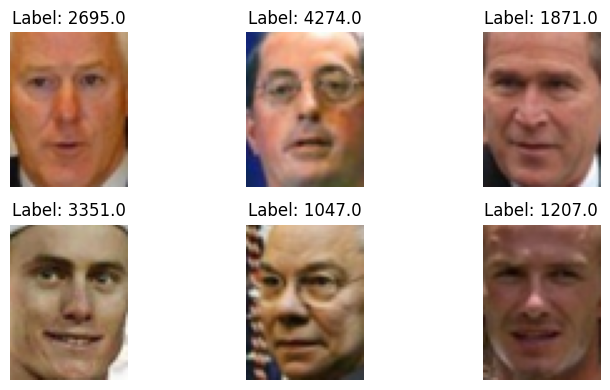

In [33]:
images, labels = next(iter(train_loader))

# Display the first 6 images in the batch
plt.figure(figsize=(8, 4))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Autoencoder Model**
An **Autoencoder** is a type of neural network that learns to **compress (encode) and reconstruct (decode) input data**.

##  **Structure**
1️⃣ **Encoder**
   - **Conv2D Layers** → Extract important features.
   - **Fully Connected Layer** → Reduce to a compressed **encoding vector**.
   - Output: **Low-dimensional representation** of the input.

2️⃣ **Decoder**
   - **Fully Connected Layer** → Expands compressed representation.
   - **Transpose Convolution Layers** → Reconstructs the input.
   - Output: **Reconstructed image** (same shape as input).

## **Expected Input & Output Shapes**
- **Input:** `(batch_size, 3, 62, 47)`  
- **Encoded Representation:** `(batch_size, encoding_dim)`  
- **Decoded Output:** `(batch_size, 3, 62, 47)`

In [34]:
# Now we are building AutoEncoders using Pytorch
class CNNAutoencoder(nn.Module):

  def __init__(self, encoding_dim = 25):
    super(CNNAutoencoder, self).__init__()

    # Encoder
    self.encoder = nn.Sequential(
      nn.Conv2d(3,32, kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.Conv2d(32,64,kernel_size=3,stride =1,padding=1),
      nn.ReLU(),
      nn.Conv2d(64,128,kernel_size=3,stride =1,padding=1),
      nn.ReLU(),
      nn.Flatten(),#128*62*47
      nn.Linear(372992, encoding_dim),
    )

    self.decoder = nn.Sequential(
      nn.Linear(encoding_dim,372992),
      nn.Unflatten(1,(128,62,47)),
      nn.ConvTranspose2d(128,64,kernel_size=3,stride=1,padding = 1),
      nn.ReLU(),
      nn.ConvTranspose2d(64,32,kernel_size=3,stride=1,padding = 1),
      nn.ReLU(),
      nn.ConvTranspose2d(32,3,kernel_size=3,stride=1,padding = 1),
      nn.Sigmoid()
    )



  def forward(self,x):
    encoder_output = self.encoder(x)
    decoder_output = self.decoder(encoder_output)
    return encoder_output, decoder_output


In [35]:
model = CNNAutoencoder()
model

CNNAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=372992, out_features=25, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=25, out_features=372992, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(128, 62, 47))
    (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Sigmoid()
  )
)

A sample Test to ensure our model is working correctly.

In [36]:
sample_tensor = torch.randn(1, 3, 62, 47) # Input shape is (B, C, H, W)
model = CNNAutoencoder()
encoder_output, decoder_output = model.forward(sample_tensor)
print(f"Encoder output shape: {encoder_output.shape}")
print(f"Decoder output shape: {decoder_output.shape}")

Encoder output shape: torch.Size([1, 25])
Decoder output shape: torch.Size([1, 3, 62, 47])


In [37]:
from tqdm import tqdm    # Shows progress bar

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode
    total_loss = 0

    for images, _ in tqdm(dataloader):  # Ignore labels since Autoencoders don't use them
        images = images.to(device)

        _, reconstructions = model(images)  # Forward pass (encoder + decoder)
        loss = criterion(reconstructions, images)  # Compute reconstruction loss

        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    return avg_loss

In [38]:
# Setup training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = model.to(device)

# MSE Loss for reconstruction
criterion = nn.MSELoss()

# Optimizer
LEARNING_RATE = 0.001
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

NUM_EPOCHS = 10

Using device: cuda


In [39]:
# Store losses for plotting
train_losses = []

# Training loop
for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss = {train_loss:.4f}")

100%|██████████| 311/311 [00:12<00:00, 25.58it/s]


Epoch 1/10, Loss = 0.0189


100%|██████████| 311/311 [00:12<00:00, 24.01it/s]


Epoch 2/10, Loss = 0.0085


100%|██████████| 311/311 [00:12<00:00, 25.68it/s]


...

Epoch 8/10, Loss = 0.0067


100%|██████████| 311/311 [00:12<00:00, 25.91it/s]


Epoch 9/10, Loss = 0.0065


100%|██████████| 311/311 [00:12<00:00, 25.77it/s]

Epoch 10/10, Loss = 0.0064


LOSS CURVE

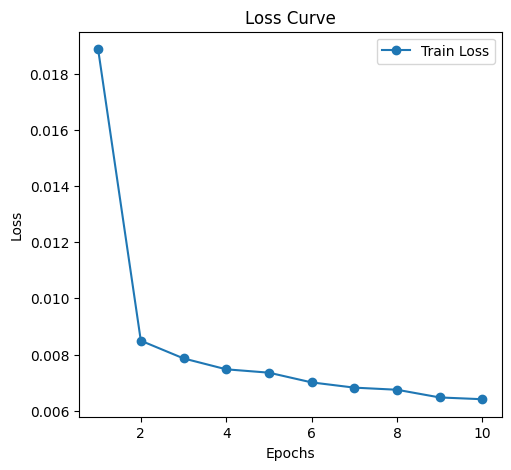

In [40]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS+1), train_losses, label="Train Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.show()

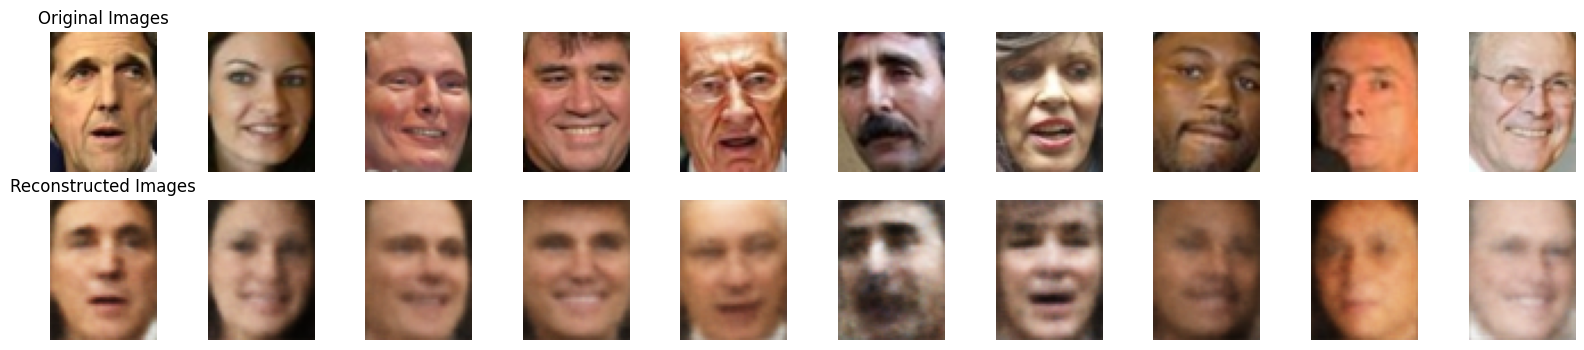

In [41]:
import matplotlib.pyplot as plt

# 🔹 Function to Display Original vs. Reconstructed Images
def show_original_vs_reconstructed(model, dataloader, device, num_images=10):
    model.eval()  # Set to evaluation mode

    # Get a batch of images
    images, _ = next(iter(dataloader))
    images = images[:num_images].to(device)  # Select 'num_images' samples

    # Get reconstructed images
    with torch.no_grad():
        _, reconstructions = model(images)
    reconstructions = reconstructions.cpu()

    # Plot original vs reconstructed images
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))

    for i in range(num_images):
        # Original images (Top row)
        axes[0, i].imshow(images[i].cpu().permute(1,2,0), cmap="gray")
        axes[0, i].axis("off")

        # Reconstructed images (Bottom row)
        axes[1, i].imshow(reconstructions[i].permute(1,2,0), cmap="gray")
        axes[1, i].axis("off")

    axes[0, 0].set_title("Original Images", fontsize=12)
    axes[1, 0].set_title("Reconstructed Images", fontsize=12)
    plt.show()

# 🔹 Display Results
show_original_vs_reconstructed(model, train_loader, device)